<a href="https://colab.research.google.com/github/rolessia/nm/blob/main/Lab10/%D0%9B%D0%A010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Рак Олеся, варіант 18, була присутня на парі

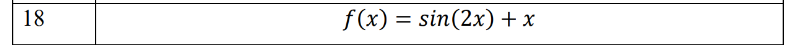

Функція f(x): x + sin(2*x)
Перша похідна f'(x): 2*cos(2*x) + 1
Друга похідна f''(x): -4*sin(2*x)
Третя похідна f'''(x): -8*cos(2*x)
Четверта похідна f''''(x): 16*sin(2*x)

Поліном Тейлора 4-го степеня T(x): -1.33333333333333*x**3 + 3.0*x
Оцінка максимальної похибки для |x| <= 1: 0.2667


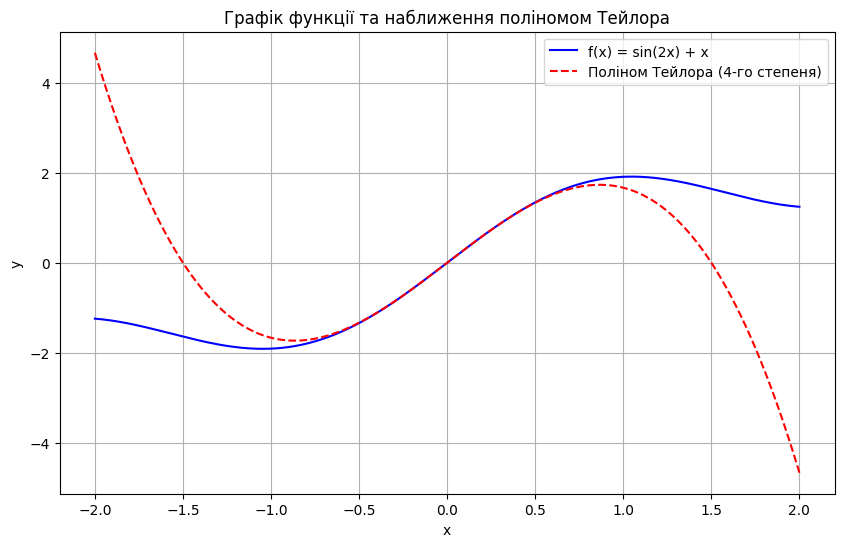

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import math

x_sym = sp.symbols('x')

f = sp.sin(2*x_sym) + x_sym

f_1 = sp.diff(f, x_sym)
f_2 = sp.diff(f_1, x_sym)
f_3 = sp.diff(f_2, x_sym)
f_4 = sp.diff(f_3, x_sym)
f_5 = sp.diff(f_4, x_sym)

print("Функція f(x):", f)
print("Перша похідна f'(x):", f_1)
print("Друга похідна f''(x):", f_2)
print("Третя похідна f'''(x):", f_3)
print("Четверта похідна f''''(x):", f_4)

x0 = 0

f_x0 = f.subs(x_sym, x0).evalf()
f1_x0 = f_1.subs(x_sym, x0).evalf()
f2_x0 = f_2.subs(x_sym, x0).evalf()
f3_x0 = f_3.subs(x_sym, x0).evalf()
f4_x0 = f_4.subs(x_sym, x0).evalf()

T = f_x0 + f1_x0*(x_sym - x0) + (f2_x0/2)*(x_sym - x0)**2 + (f3_x0/6)*(x_sym - x0)**3 + (f4_x0/24)*(x_sym - x0)**4
print("\nПоліном Тейлора 4-го степеня T(x):", T)

max_f5 = 32
max_error = (max_f5 / math.factorial(5)) * (1**5)
print(f"Оцінка максимальної похибки для |x| <= 1: {max_error:.4f}")

f_func = sp.lambdify(x_sym, f, 'numpy')
T_func = sp.lambdify(x_sym, T, 'numpy')

x_vals = np.linspace(-2, 2, 1000)
f_vals = f_func(x_vals)
T_vals = T_func(x_vals)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, f_vals, label='f(x) = sin(2x) + x', color='blue')
ax.plot(x_vals, T_vals, label='Поліном Тейлора (4-го степеня)', color='red', linestyle='--')

ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Графік функції та наближення поліномом Тейлора")
plt.grid(True)
plt.show()

Поліном Тейлора:
         4         3         2
0.2253 x - 1.146 x - 0.169 x + 2.984 x + 0.01408


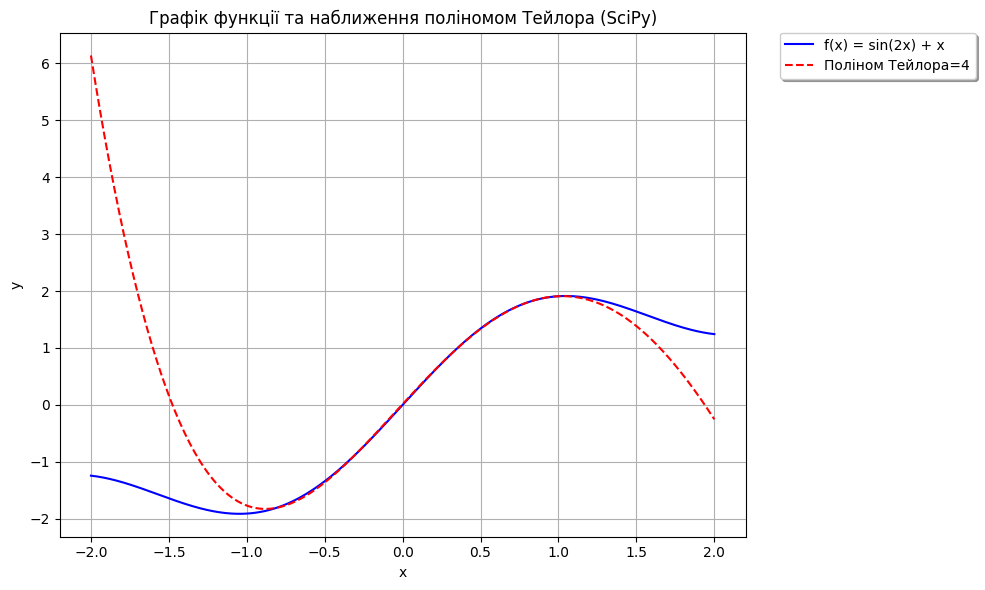

In [7]:
from scipy.interpolate import approximate_taylor_polynomial

def f(x):
    return np.sin(2*x) + x

x_vals = np.linspace(-2.0, 2.0, num=400)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, f(x_vals), label="f(x) = sin(2x) + x", color='blue')

degree = 4

taylor = approximate_taylor_polynomial(f, 0, degree, 1)
print('Поліном Тейлора:\n', taylor)

plt.plot(x_vals, taylor(x_vals), label=f"Поліном Тейлора={degree}", color='red', linestyle='--')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.0, shadow=True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Графік функції та наближення поліномом Тейлора (SciPy)")
plt.tight_layout()
plt.grid(True)
plt.show()

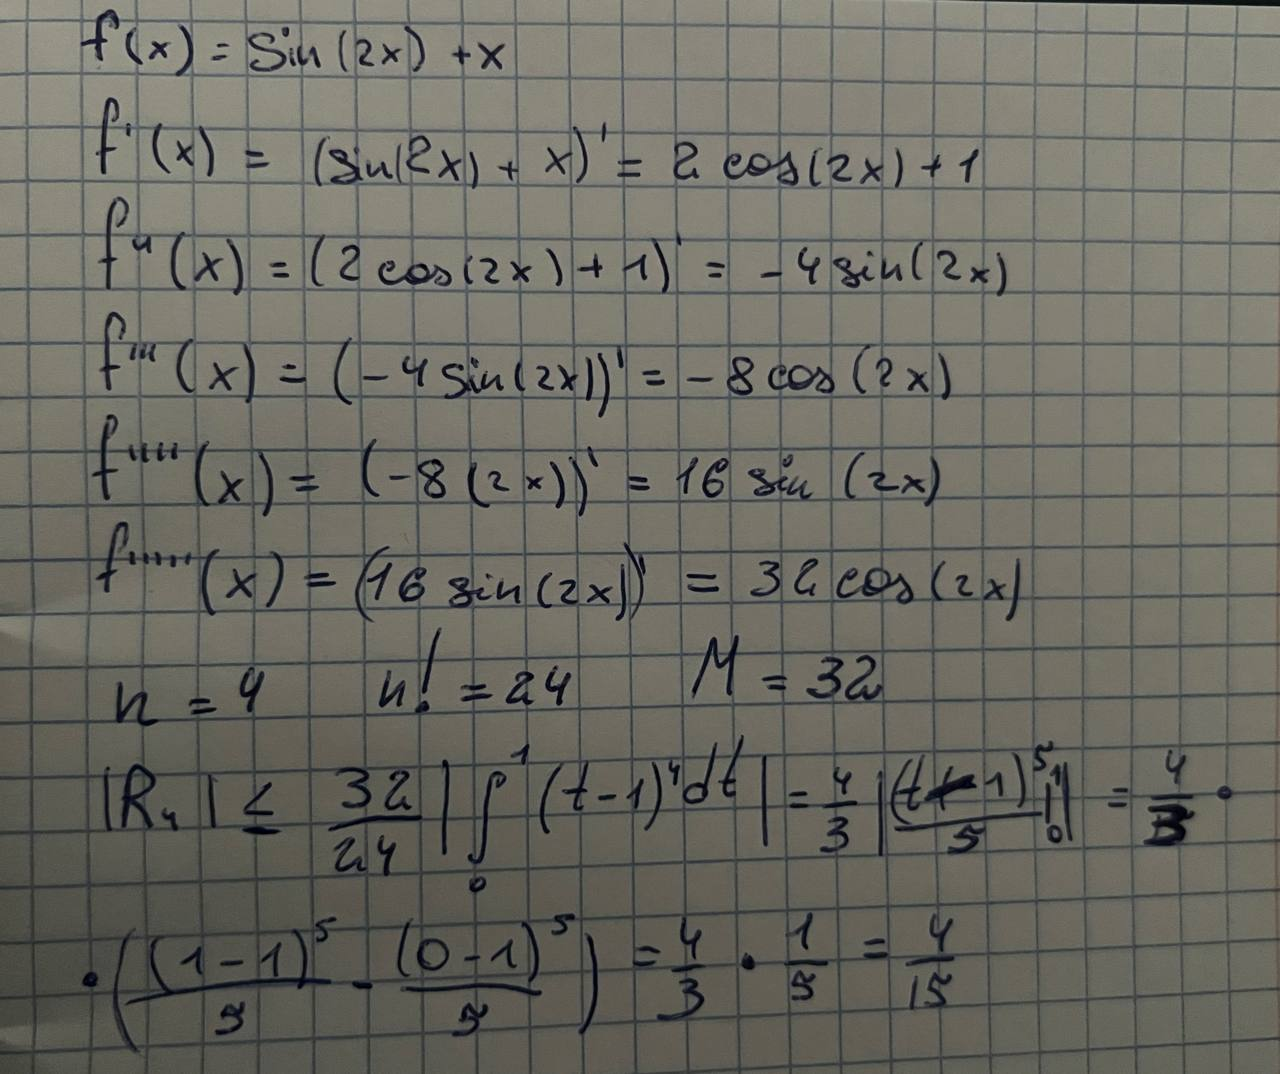